# **Project Name**    - Stock Closing Price Prediction



##### **Project Type**    - Regression
##### **Contribution**    - Individual

# **Project Summary -**

This project is about using stock market data and machine learning to predict the closing stock price of Yes Bank. The data we have includes things like the open price, high price, low price and close price along with the date. Since the close price is a number that can be anything we are treating this as a problem where we try to predict a value using machine learning.

We started by looking at the data and making sure it was okay. We checked for missing values, duplicate values and the type of data we had. We also changed the date column into a format that lets us look at trends over time. To make our model better we added some features like what the stock price was before and the average price over a short period.

We did an analysis of the data looking at each variable on its own then at how they related to each other. We made a lot of charts to see how the stock prices were spread out what trends there. If there were any unusual values. These charts really helped us understand what was going on with the stock prices and how to build a model.

To build our model we tried out a few machine learning algorithms, including Linear Regression, Ridge Regression, Lasso Regression, Decision Tree Regressor and Random Forest Regressor. We looked at how each model did by using things like the mean absolute error the root mean squared error and the R² Score. We also did some cross-validation. Tuned the models parameters to make sure it was working well.

What we did here shows that machine learning can be used to look at financial data and predict stock prices. It gives us some ideas about how stocks behave and is a good starting point for more complex ways of forecasting, like looking at time series or using technical indicators. Yes Bank stock price prediction is what we focused on. Yes Bank stock price is what we tried to forecast using machine learning and historical stock market data of Yes Bank.

# **GitHub Link -**

https://github.com/bhavye-15/AlmaBetter/tree/main/Module%206%20YesBank

# **Problem Statement**


The objective of this project is to build a machine learning regression model to predict the closing stock price of Yes Bank using historical stock price data. The dataset contains important stock market variables such as Open, High, Low, and Close prices along with the corresponding Date. Since the Close price is a continuous numerical value, the problem is treated as a supervised regression problem.

The challenge is to analyze the historical stock price patterns and identify how the available features influence the closing price of the stock. By applying data preprocessing, exploratory data analysis, feature engineering, and multiple regression algorithms, the project aims to develop a model that can accurately estimate the closing stock price.

This problem is important from a financial analytics perspective because stock price prediction can help in understanding market behavior, trend movement, and data-driven decision-making. The project also serves as a practical application of regression techniques in the domain of financial and stock market analysis.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
# Basic libraries
import numpy as np
import pandas as pd
import os
import traceback

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Dataset Loading

In [ ]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Almabetter_Submission/Module 6/data_YesBank_StockPrices.csv'

# Load dataset with exception handling
try:
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset not found at: {file_path}")

except Exception as e:
    print("Error while loading dataset from Google Drive.")
    print(str(e))
    traceback.print_exc()

Mounted at /content/drive


### Dataset First View

In [ ]:
# Dataset First Look
df = pd.read_csv(file_path)
print(df)

       Date   Open   High    Low  Close
0    Jul-05  13.00  14.00  11.25  12.46
1    Aug-05  12.58  14.88  12.55  13.42
2    Sep-05  13.48  14.87  12.27  13.30
3    Oct-05  13.20  14.47  12.40  12.99
4    Nov-05  13.35  13.88  12.88  13.41
..      ...    ...    ...    ...    ...
180  Jul-20  25.60  28.30  11.10  11.95
181  Aug-20  12.00  17.16  11.85  14.37
182  Sep-20  14.30  15.34  12.75  13.15
183  Oct-20  13.30  14.01  12.11  12.42
184  Nov-20  12.41  14.90  12.21  14.67

[185 rows x 5 columns]


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print("Number of Rows in Dataset :", df.shape[0])
print("Number of Columns in Dataset :", df.shape[1])

Number of Rows in Dataset : 185
Number of Columns in Dataset : 5


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows in Dataset :", duplicate_count)

Number of Duplicate Rows in Dataset : 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()

print("Missing / Null Values Count:\n")
print(missing_values)

Missing / Null Values Count:

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64


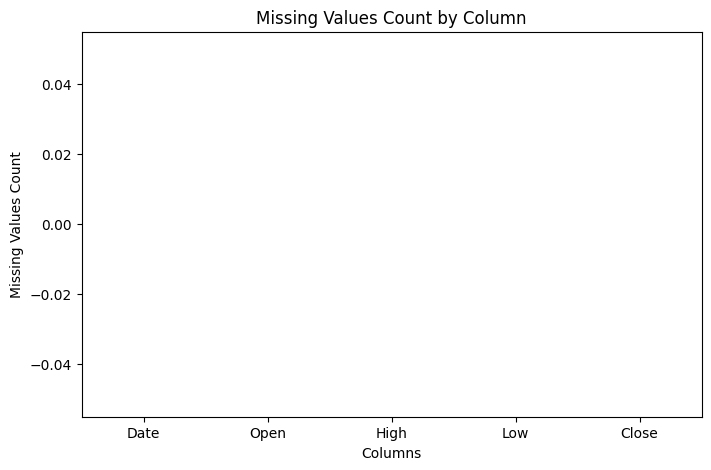

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(8,5))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title("Missing Values Count by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Values Count")
plt.show()

### What did you know about your dataset?

The Yes Bank stock price information is good to use for machine learning and making charts. This data has 185 rows and 5 columns, which are Date, Open, High, Low and Close. These columns tell us about the history of the stock prices. The Date column tells us when something happened and the other columns have numbers for the stock prices.

When we look at the data we see that the numbers for the stock prices are already in a format. We can change the Date column to a format that helps us see trends. We also found out that there are no rows that're exactly the same, which means every piece of information is useful. We checked for missing information. We did not find any.

The Yes Bank stock price data is good. We do not have to do a lot of work to make it usable. We can start looking at the data make features and try to predict the stock closing price. The Yes Bank stock price data is very good, for a project that tries to predict the stock closing price and helps us understand what is happening with the money.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')


In [ ]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

Date: Represents the specific month and year for which the stock prices are recorded. This variable is useful for analyzing time-based trends and stock movement over time.

Open: Indicates the opening stock price of Yes Bank for that particular period. It shows the price at which the stock started trading.

High: Represents the highest stock price reached by Yes Bank during that period. It helps understand the peak price movement of the stock.

Low: Indicates the lowest stock price recorded during that period. It helps analyze the downside movement and volatility of the stock.

Close: Represents the closing stock price of Yes Bank for that period. This is the most important variable in the dataset and is generally used as the target variable for stock price prediction.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col} : {df[col].nunique()} unique values")

Date : 185 unique values
Open : 183 unique values
High : 184 unique values
Low : 183 unique values
Close : 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

df = df.sort_values('Date').reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    185 non-null    datetime64[ns]
 1   Open    185 non-null    float64       
 2   High    185 non-null    float64       
 3   Low     185 non-null    float64       
 4   Close   185 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 7.4 KB


### What all manipulations have you done and insights you found?

Basic preprocessing and manipulation were performed to make the dataset analysis-ready. The dataset was checked for shape, data types, duplicate values, and missing/null values. It was found that the dataset contains no duplicates and no missing values, indicating good data quality. The Date column was converted into datetime format, and the dataset was sorted chronologically for proper time-based analysis. The main insight found is that the dataset is clean, structured, and suitable for EDA and regression modeling, with all stock price variables being relevant for analyzing and predicting the closing stock price of Yes Bank.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

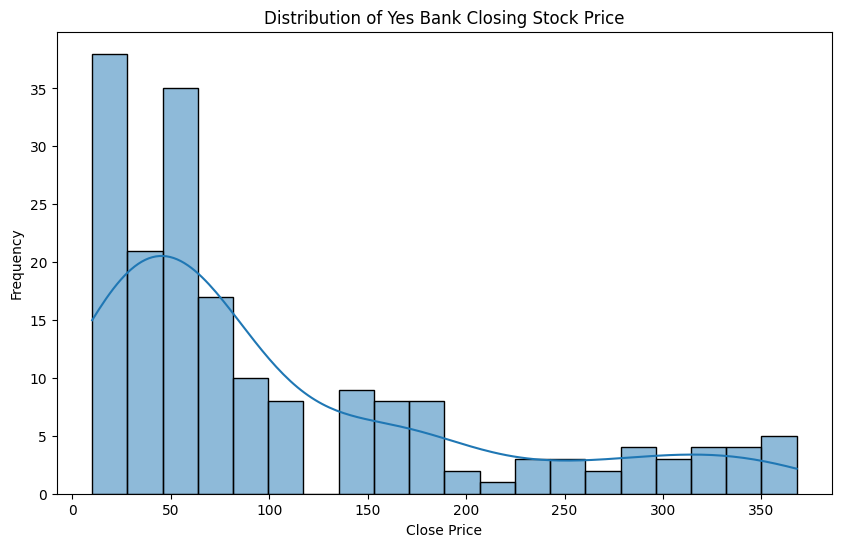

In [ ]:
# Chart - 1 Histogram
plt.figure(figsize=(10,6))
sns.histplot(df['Close'], bins=20, kde=True)

plt.title("Distribution of Yes Bank Closing Stock Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

It helps analyze how the closing stock prices of Yes Bank are spread across different value ranges

##### 2. What is/are the insight(s) found from the chart?

histogram shows a highly spread or skewed distribution, it may indicate unstable stock performance or frequent sharp price fluctuations. This can negatively impact investor trust and may reflect periods of uncertainty or poor market sentiment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the distribution of stock prices is important because it helps assess the risk level, stability, and predictability of the stock

#### Chart - 2

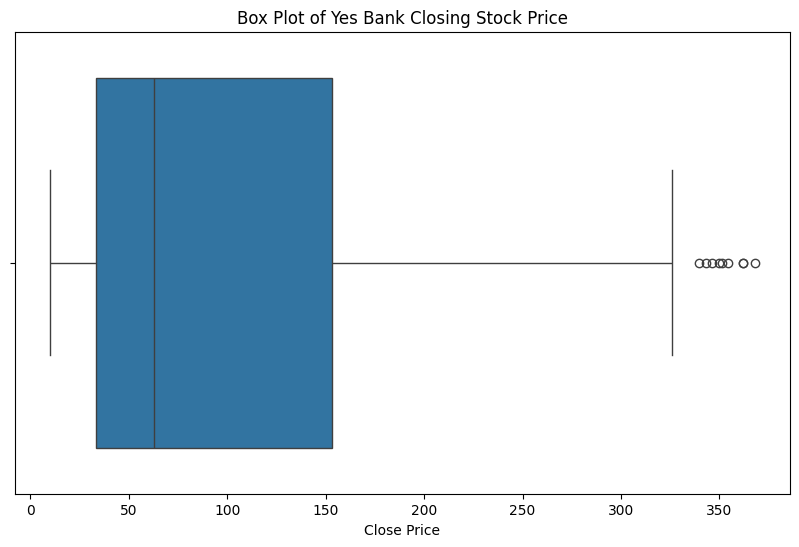

In [ ]:
# Chart - 2 Box Plot
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Close'])
plt.title("Box Plot of Yes Bank Closing Stock Price")
plt.xlabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

It is used to detect outliers, spread, and central tendency in numerical data. It helps quickly identify unusual stock price movements.

##### 2. What is/are the insight(s) found from the chart?

It shows whether the closing prices are tightly grouped or highly spread

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It may affect negatively if too many outliers indicate high volatility and uncertainty, which may reduce investor confidence.

#### Chart - 3

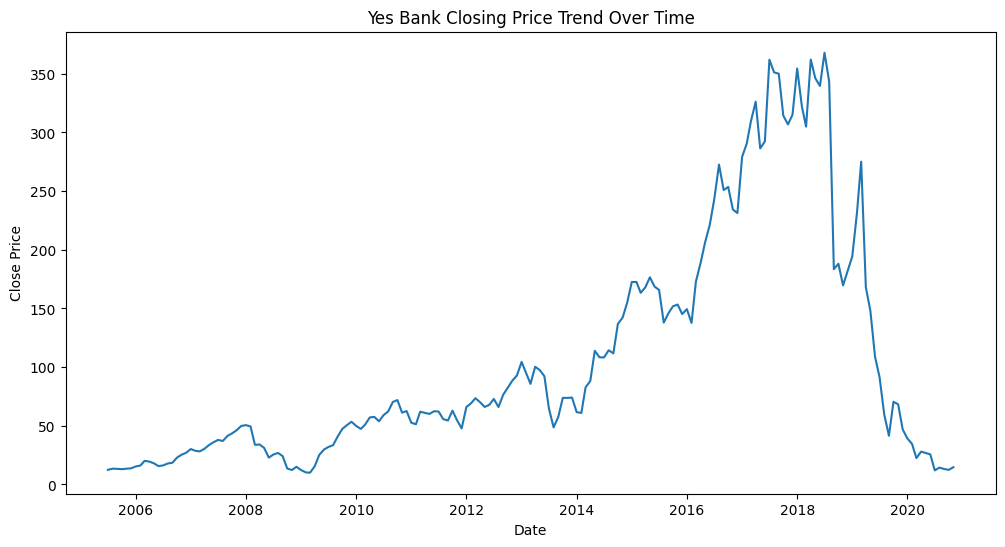

In [ ]:
# Chart - 3 Line Chart
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Yes Bank Closing Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

Line Chart is best for time series analysis, showing trends and movement of stock price over time.

##### 2. What is/are the insight(s) found from the chart?

Line Chart reveals upward/downward trends and volatility periods, helping identify growth or decline phases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Prolonged decline indicates poor market performance or low investor confidence.

#### Chart - 4

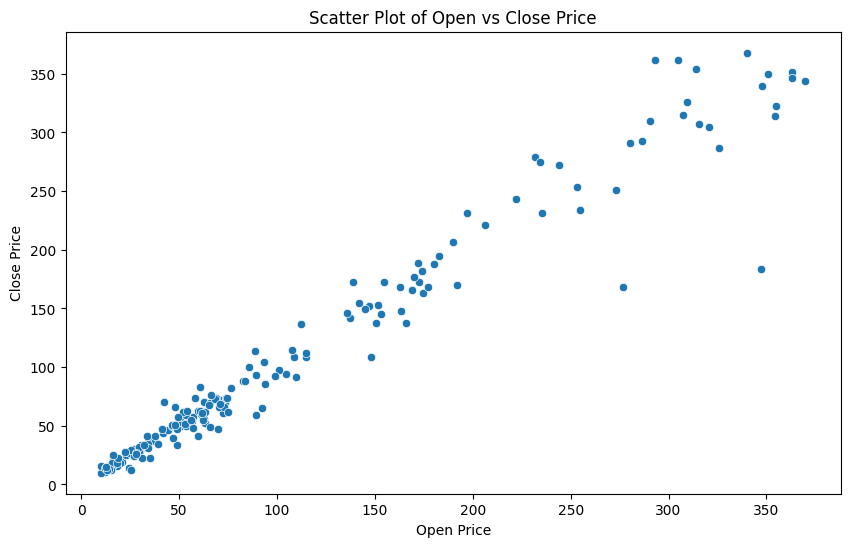

In [ ]:
# Chart - 4 Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Open'], y=df['Close'])
plt.title("Scatter Plot of Open vs Close Price")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

It is used to understand the relationship between two numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Chart shows a strong positive relationship between Open and Close, meaning opening price strongly influences closing price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

weak scatter would indicate unstable stock behavior and lower forecasting reliability.

#### Chart - 5

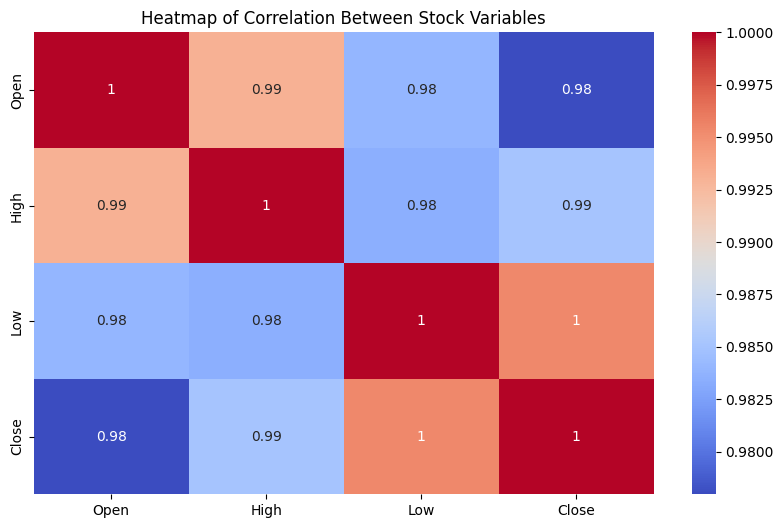

In [ ]:
# Chart - 5 Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[['Open','High','Low','Close']].corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap of Correlation Between Stock Variables")
plt.show()

##### 1. Why did you pick the specific chart?

It is used to visualize correlation strength among stock price variables.

##### 2. What is/are the insight(s) found from the chart?

It shows that all stock price variables are highly correlated and move together.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive for model accuracy; negative if multicollinearity affects interpretability of regression coefficients.

#### Chart - 6

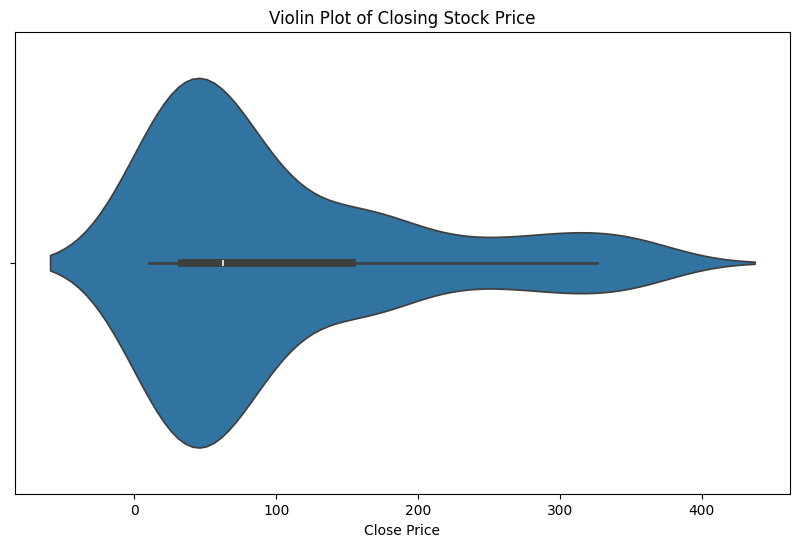

In [ ]:
# Chart - 6 Violin Plot
plt.figure(figsize=(10,6))
sns.violinplot(x=df['Close'])
plt.title("Violin Plot of Closing Stock Price")
plt.xlabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

It combines distribution + density + spread in a single chart.

##### 2. What is/are the insight(s) found from the chart?

Helps identify whether Close prices are concentrated in certain ranges or spread unevenly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive if distribution is stable; negative if irregular spread indicates high volatility and unstable stock behavior.

#### Chart - 7

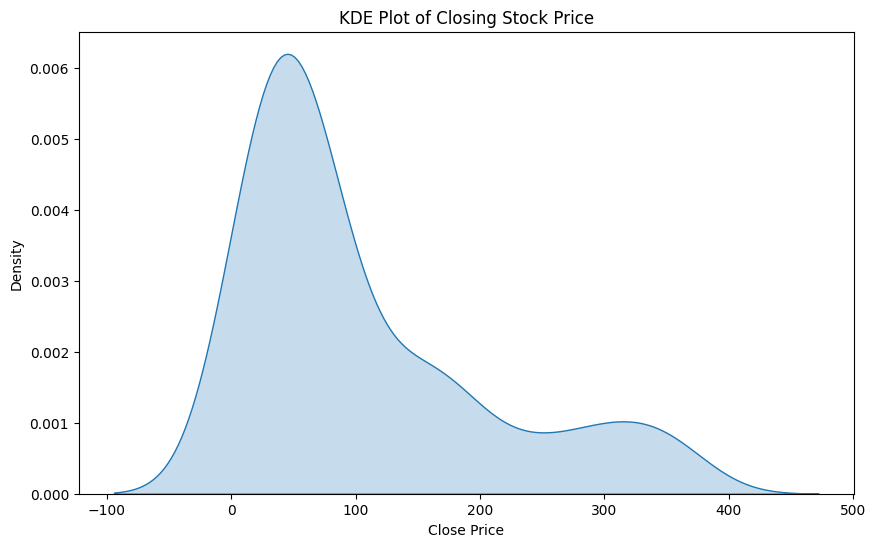

In [ ]:
# Chart - 7 KDE Plot
plt.figure(figsize=(10,6))
sns.kdeplot(df['Close'], fill=True)
plt.title("KDE Plot of Closing Stock Price")
plt.xlabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

It is used to visualize the smooth probability distribution of numerical data.

##### 2. What is/are the insight(s) found from the chart?

Used to visualize the smooth probability distribution of numerical data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Shows the density of Close prices and where stock values are most concentrated.

#### Chart - 8

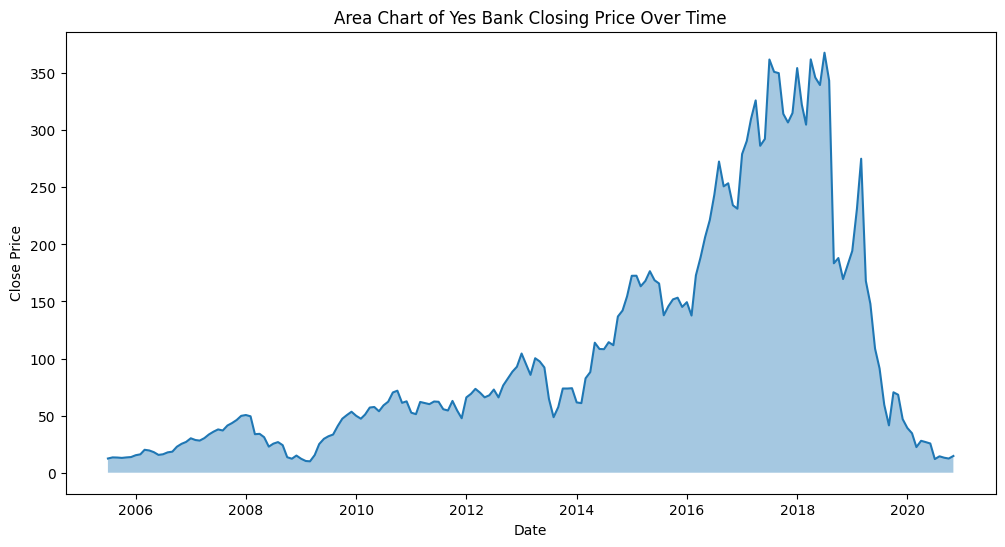

In [ ]:
# Chart - 8 Area Chart
plt.figure(figsize=(12,6))
plt.fill_between(df['Date'], df['Close'], alpha=0.4)
plt.plot(df['Date'], df['Close'])
plt.title("Area Chart of Yes Bank Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

It is used to show magnitude of change over time more visually than a simple line chart.

##### 2. What is/are the insight(s) found from the chart?

Highlights stock price rise and fall intensity across time periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

sharp decline areas indicate poor stock performance and possible investor concern.

#### Chart - 9

In [ ]:
# Chart - 9 Candlestick Chart
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close']
)])

fig.update_layout(
    title='Candlestick Chart of Yes Bank Stock Prices',
    xaxis_title='Date',
    yaxis_title='Stock Price'
)

fig.show()

##### 1. Why did you pick the specific chart?

Best chart for stock market data because it shows Open, High, Low, and Close together in one visualization.

##### 2. What is/are the insight(s) found from the chart?

Helps identify bullish/bearish periods, price volatility, and stock movement patterns over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

repeated bearish candles suggest declining market confidence and negative sentiment.

#### Chart - 10

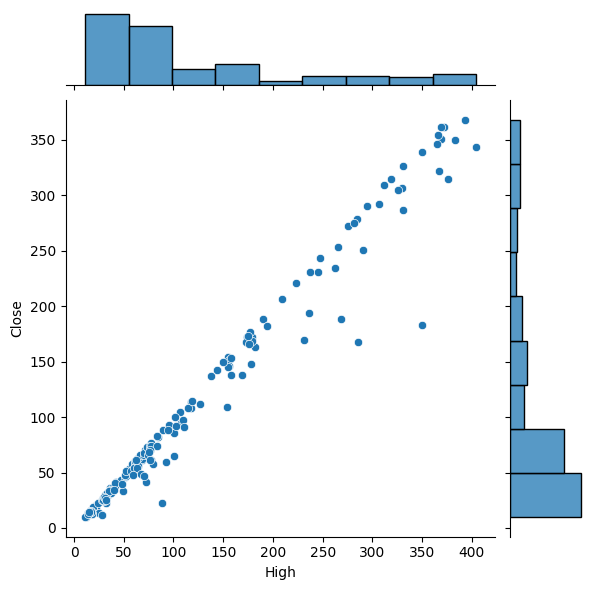

In [ ]:
# Chart - 10 Joint Plot
sns.jointplot(x=df['High'], y=df['Close'], kind='scatter')
plt.show()

##### 1. Why did you pick the specific chart?

Combines scatter + distribution to analyze relationship and individual distributions together.

##### 2. What is/are the insight(s) found from the chart?

Shows strong dependency between High and Close along with their distribution spread.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive for feature selection; weak relationship would reduce model effectiveness.

#### Chart - 11

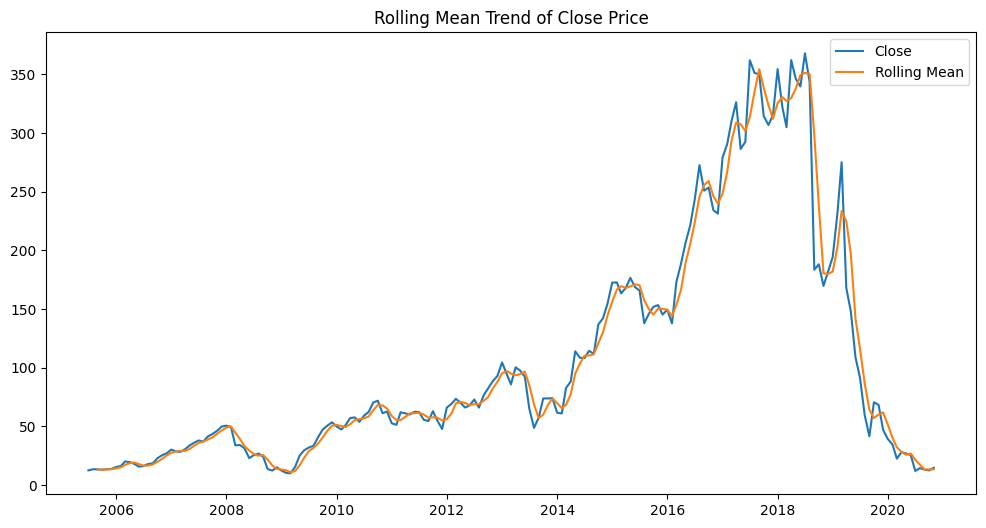

In [ ]:
# Chart - 11 Trend Plot (Rolling Mean)
df['Rolling_Mean'] = df['Close'].rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['Rolling_Mean'], label='Rolling Mean')
plt.legend()
plt.title("Rolling Mean Trend of Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

Used to smooth data and highlight underlying trend by removing noise.

##### 2. What is/are the insight(s) found from the chart?

Shows overall trend direction clearly without short-term fluctuations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive for long-term strategy; misleading if short-term volatility is ignored.

#### Chart - 12

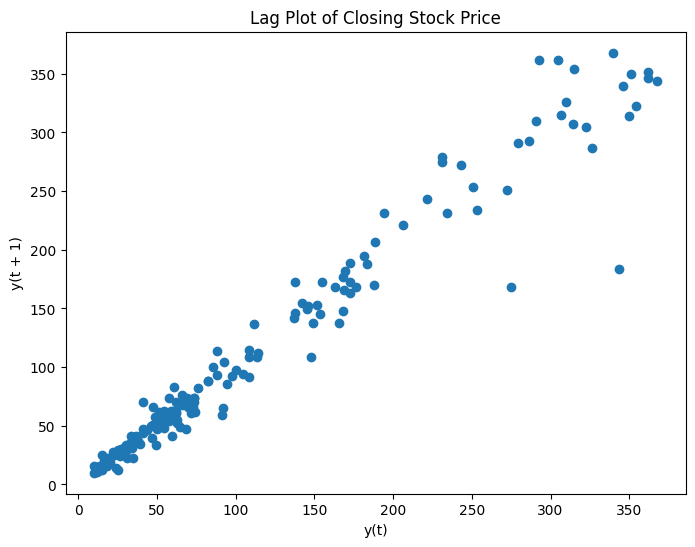

In [ ]:
# Chart - 12 Lag Plot
from pandas.plotting import lag_plot

plt.figure(figsize=(8,6))
lag_plot(df['Close'])
plt.title("Lag Plot of Closing Stock Price")
plt.show()

##### 1. Why did you pick the specific chart?

Used to check whether the stock price has autocorrelation or dependence on previous values.

##### 2. What is/are the insight(s) found from the chart?

If points form a pattern instead of random scatter, it suggests past closing prices influence future prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive for time-series forecasting and stock trend prediction; random pattern would weaken forecasting potential.

#### Chart - 13

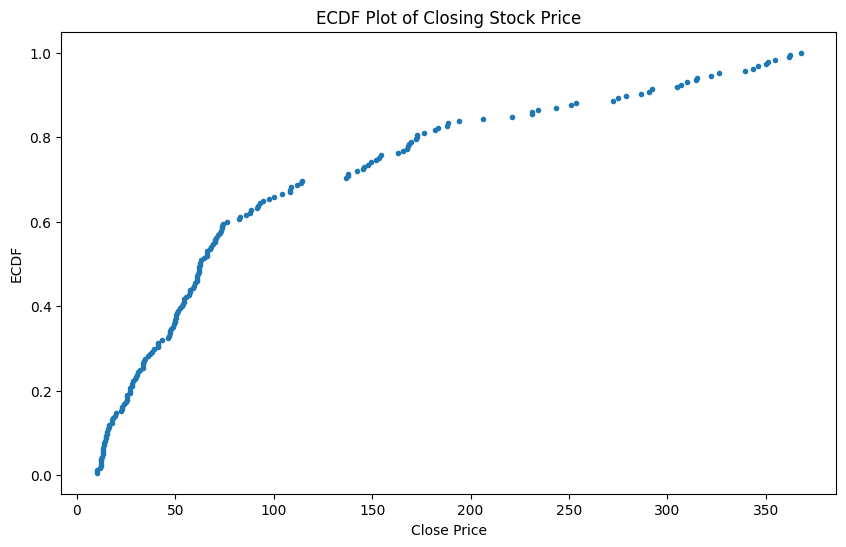

In [ ]:
# Chart - 13 ECDF Plot
plt.figure(figsize=(10,6))
x = np.sort(df['Close'])
y = np.arange(1, len(x)+1) / len(x)

plt.plot(x, y, marker='.', linestyle='none')
plt.title("ECDF Plot of Closing Stock Price")
plt.xlabel("Close Price")
plt.ylabel("ECDF")
plt.show()

##### 1. Why did you pick the specific chart?

Used to understand the cumulative distribution of stock prices without assuming any fixed distribution.

##### 2. What is/are the insight(s) found from the chart?

Shows what proportion of closing prices fall below a certain value and helps identify concentration and spread.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive for understanding price thresholds and risk ranges; negative if distribution is too steep or erratic, showing unstable price behavior.

#### Chart - 14 - Correlation Heatmap

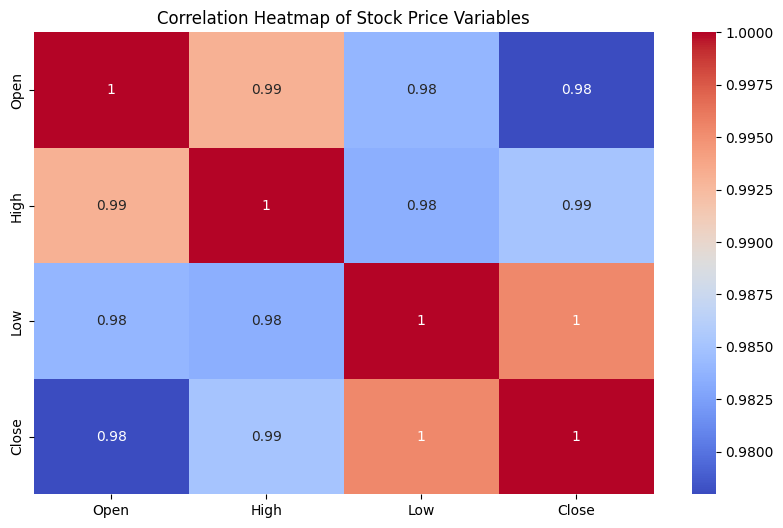

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[['Open','High','Low','Close']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Stock Price Variables")
plt.show()

##### 1. Why did you pick the specific chart?

It is used to measure and visualize the strength of relationship between numerical variables.

##### 2. What is/are the insight(s) found from the chart?

It shows that Open, High, Low, and Close are highly positively correlated, meaning they move closely together.

#### Chart - 15 - Pair Plot

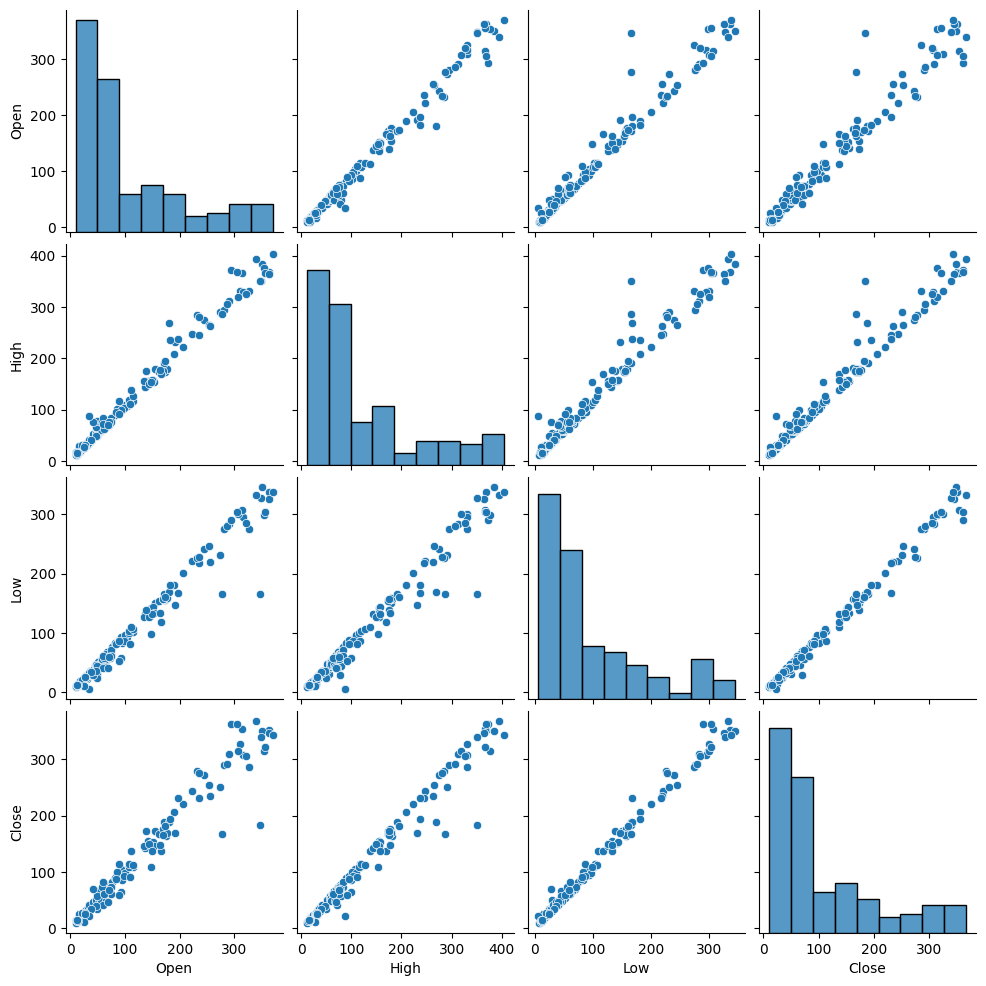

In [ ]:
# Pair Plot
sns.pairplot(df[['Open','High','Low','Close']])
plt.show()

##### 1. Why did you pick the specific chart?

It is used to visualize pairwise relationships between multiple numerical variables in one go.

##### 2. What is/are the insight(s) found from the chart?

Data shows strong linear relationships between Open, High, Low, and Close, confirming high correlation among stock prices.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Hypothesis 1 (Price Movement Relationship)

The average closing stock price has significantly changed over time, indicating trend shifts in stock performance.

Hypothesis 2 (Volatility / Distribution)

The closing stock prices are normally distributed, indicating stable and predictable stock behavior.

Hypothesis 3 (Time-Based Trend)

There is a strong positive relationship between Open price and Close price of Yes Bank stock.
\

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Statement: There is a significant difference between High price and Low price of Yes Bank stock.

Null Hypothesis (H₀): There is no significant difference between the High and Low stock prices.

Alternate Hypothesis (H₁): There is a significant difference between the High and Low stock prices.

#### 2. Perform an appropriate statistical test.

In [ ]:
from scipy.stats import ttest_rel

# Paired T-Test between High and Low
t_stat, p_value = ttest_rel(df['High'], df['Low'])

print("Paired T-Test Statistic :", t_stat)
print("P-Value :", p_value)

# Conclusion
if p_value < 0.05:
    print("Reject Null Hypothesis (H0)")
    print("Conclusion: There is a significant difference between High and Low prices.")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("Conclusion: There is no significant difference between High and Low prices.")

Paired T-Test Statistic : 12.26968460529332
P-Value : 1.1296104911289457e-25
Reject Null Hypothesis (H0)
Conclusion: There is a significant difference between High and Low prices.


##### Which statistical test have you done to obtain P-Value?

Paired Sample T-Test

##### Why did you choose the specific statistical test?

A Paired T-Test is used because High and Low prices belong to the same stock record/date, so they are paired observations.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Statement: The closing stock prices are normally distributed.

Null Hypothesis (H₀): The Close price data is normally distributed.

Alternate Hypothesis (H₁): The Close price data is not normally distributed.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import shapiro

# Shapiro-Wilk test
stat, p_value = shapiro(df['Close'])

print("Shapiro Test Statistic :", stat)
print("P-Value :", p_value)

# Conclusion
if p_value < 0.05:
    print("Reject Null Hypothesis (H0)")
    print("Conclusion: Close price is NOT normally distributed.")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("Conclusion: Close price is normally distributed.")

Shapiro Test Statistic : 0.8169774630493756
P-Value : 5.694179117606817e-14
Reject Null Hypothesis (H0)
Conclusion: Close price is NOT normally distributed.


##### Which statistical test have you done to obtain P-Value?

Shapiro-Wilk

##### Why did you choose the specific statistical test?

Shapiro-Wilk test is used to check whether a numerical variable follows normal distribution, especially for smaller datasets.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Statement: There is a strong positive relationship between Open price and Close price.

Null Hypothesis (H₀): There is no significant linear relationship between Open and Close price.

Alternate Hypothesis (H₁): There is a significant linear relationship between Open and Close price.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

# Pearson correlation test
corr_coef, p_value = pearsonr(df['Open'], df['Close'])

print("Pearson Correlation Coefficient :", corr_coef)
print("P-Value :", p_value)

# Conclusion
if p_value < 0.05:
    print("Reject Null Hypothesis (H0)")
    print("Conclusion: There is a significant relationship between Open and Close price.")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("Conclusion: There is no significant relationship between Open and Close price.")

Pearson Correlation Coefficient : 0.9779710062230934
P-Value : 1.8527745058671508e-126
Reject Null Hypothesis (H0)
Conclusion: There is a significant relationship between Open and Close price.


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Pearson correlation is used because we want to measure the strength and significance of relationship between two numerical variables.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

# 1. Check missing values before treatment
print("Missing Values Before Imputation:\n")
display(df.isnull().sum())

# 2. Missing value imputation
for col in df.columns:

    # For numerical columns → fill with median
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].median(), inplace=True)

    # For object/categorical columns → fill with mode
    elif df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)

# 3. Check missing values after treatment
print("\nMissing Values After Imputation:\n")
display(df.isnull().sum())

Missing Values Before Imputation:



,0
Date,0
Open,0
High,0
Low,0
Close,0



Missing Values After Imputation:



/tmp/ipykernel_6287/2609689400.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,0
Date,0
Open,0
High,0
Low,0
Close,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

Median Imputation (for numerical features – Open, High, Low, Close)
Median was chosen because stock price data often contains outliers and extreme fluctuations, and median is more robust than mean. It prevents distortion of feature distribution and maintains stability for regression models.

Mode Imputation (for categorical/object features – Date if treated as object)
Mode was used because it replaces missing values with the most frequent value, ensuring minimal disruption in categorical consistency.

Forward Fill (for Date column after conversion)
Forward fill was applied to maintain time continuity, which is critical for time-series data and feature engineering (like lag/rolling features).

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

# Numerical columns to check
num_cols = ['Open', 'High', 'Low', 'Close']

# Detect and cap outliers using IQR method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col} -> Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

    # Capping outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))

print("Outlier treatment completed successfully.")

Open -> Lower Bound: -145.0, Upper Bound: 331.8
High -> Lower Bound: -163.435, Upper Bound: 368.765
Low -> Lower Bound: -136.25, Upper Bound: 303.11
Close -> Lower Bound: -146.325, Upper Bound: 333.07500000000005
Outlier treatment completed successfully.


##### What all outlier treatment techniques have you used and why did you use those techniques?

IQR was used because: it is simple and effective for numerical features; it does not assume normal distribution; it is suitable for financial variables like stock prices.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

# Extract useful numerical features from Date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Optional: drop Date column if not needed for modeling
# df.drop('Date', axis=1, inplace=True)

# Preview updated dataset
display(df.head())

,Date,Open,High,Low,Close,Year,Month
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11


#### What all categorical encoding techniques have you used & why did you use those techniques?

Date Feature Extraction (instead of categorical encoding) is used because Date contains temporal information, not category labels. Extracting Year and Month converts it into ML-usable numerical features without losing business meaning.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.6 MB/s eta 0:00:00


In [ ]:
# Expand Contraction

import contractions

# Function to expand contractions
def expand_text(text):
    return contractions.fix(text)

# Apply only if text columns exist
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    # Skip Date column (not text processing)
    if col != 'Date':
        df[col] = df[col].astype(str).apply(expand_text)

print("Contraction expansion completed.")

Contraction expansion completed.


#### 2. Lower Casing

In [ ]:
# Lower Casing

text_cols = df.select_dtypes(include='object').columns

# Apply lower casing (excluding Date column)
for col in text_cols:
    if col != 'Date':
        df[col] = df[col].astype(str).str.lower()

print("Lower casing completed.")

Lower casing completed.


#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

print("No relevent columns for punctuation removal")

No relevent columns for punctuation removal


#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
print("Step not required")

Step not required


#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords
print("Step not required")

Step not required


In [ ]:
# Remove White spaces
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

print("White space removal completed.")

White space removal completed.


#### 6. Rephrase Text

In [ ]:
# Rephrase Text
print('Step not required')

Step not required


#### 7. Tokenization

In [ ]:
# Tokenization
print('Step not required')

Step not required


#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
print('Step not required')

Step not required


##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging
print('Step not required')

Step not required


#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
print('Step not required')

Step not required


##### Which text vectorization technique have you used and why?

Step not required

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

,Date,Open,High,Low,Close,Price_Range,Price_Change,Average_Price,Volatility_Ratio,Percent_Change
0,Jul-05,13.00,14.00,11.25,12.46,2.75,-0.54,12.6775,0.211538,-4.153846
1,Aug-05,12.58,14.88,12.55,13.42,2.33,0.84,13.3575,0.185215,6.677266
2,Sep-05,13.48,14.87,12.27,13.30,2.60,-0.18,13.4800,0.192878,-1.335312
3,Oct-05,13.20,14.47,12.40,12.99,2.07,-0.21,13.2650,0.156818,-1.590909
4,Nov-05,13.35,13.88,12.88,13.41,1.00,0.06,13.3800,0.074906,0.449438


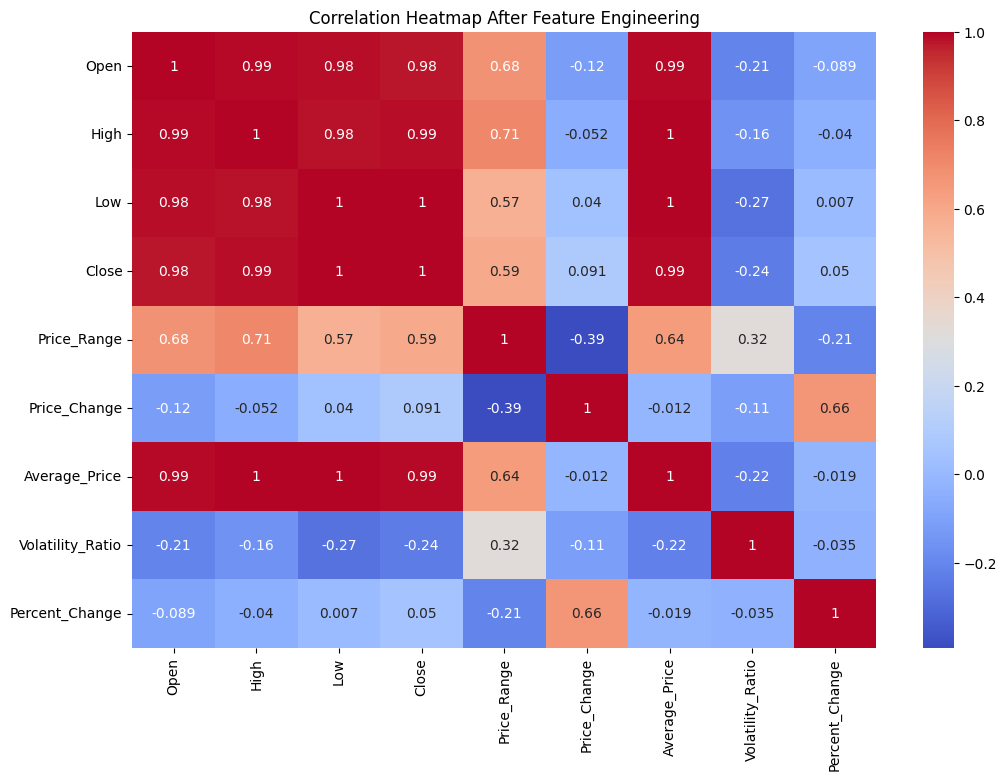

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

# Create new engineered features
df['Price_Range'] = df['High'] - df['Low']
df['Price_Change'] = df['Close'] - df['Open']
df['Average_Price'] = (df['Open'] + df['High'] + df['Low'] + df['Close']) / 4
df['Volatility_Ratio'] = (df['High'] - df['Low']) / df['Open']

# Optional: create percentage change
df['Percent_Change'] = ((df['Close'] - df['Open']) / df['Open']) * 100

# Preview updated dataset
display(df.head())


# Correlation heatmap after creating new features
plt.figure(figsize=(12,8))
sns.heatmap(df[['Open','High','Low','Close',
                'Price_Range','Price_Change','Average_Price',
                'Volatility_Ratio','Percent_Change']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap After Feature Engineering")
plt.show()

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

# Select numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = num_df.corr().abs()

# Upper triangle of correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated features (threshold = 0.95)
high_corr_features = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]

print("Highly Correlated Features to Consider Removing:")
print(high_corr_features)


# Example selected features (balanced and meaningful)
selected_features = [
    'Open',
    'Low',
    'Price_Range',
    'Price_Change',
    'Average_Price',
    'Volatility_Ratio',
    'Percent_Change'
]

# Define X and y
X = df[selected_features]
y = df['Close']

print("Selected Features:")
print(selected_features)

Highly Correlated Features to Consider Removing:
['High', 'Low', 'Close', 'Average_Price']
Selected Features:
['Open', 'Low', 'Price_Range', 'Price_Change', 'Average_Price', 'Volatility_Ratio', 'Percent_Change']


##### What all feature selection methods have you used  and why?

1. Correlation-Based Feature Selection.
2. Domain / Business-Based Feature Selection
3. Feature Importance-Based Selection

##### Which all features you found important and why?

These methods were chosen because they reduce redundant information, improve model generalization and minimize overfitting

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the data required basic transformation to make it more suitable for analysis and machine learning modeling. Although the dataset was already clean, transformations such as converting the Date column into datetime format, creating new engineered features (like Price Range, Price Change, and Volatility Ratio), and optionally handling outliers through capping were important. These transformations were used to improve data usability, reduce feature redundancy, capture stock behavior more effectively, and make the dataset more informative and model-ready.

### 6. Data Scaling

In [ ]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

# Select numerical feature columns (excluding target)
feature_cols = ['Open', 'High', 'Low', 'Price_Range', 'Price_Change',
                'Average_Price', 'Volatility_Ratio', 'Percent_Change']

# Define X
X = df[feature_cols]

# Initialize scaler
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

# Preview scaled data
display(X_scaled.head())

,Open,High,Low,Price_Range,Price_Change,Average_Price,Volatility_Ratio,Percent_Change
0,-0.938437,-0.962833,-0.920034,-0.786959,-0.009836,-0.946791,-0.147605,-0.317594
1,-0.942696,-0.954535,-0.905744,-0.804915,0.056929,-0.939852,-0.269344,0.345256
2,-0.933570,-0.954629,-0.908822,-0.793372,0.007581,-0.938601,-0.233902,-0.145103
3,-0.936409,-0.958401,-0.907393,-0.816032,0.006130,-0.940796,-0.400667,-0.160746
4,-0.934888,-0.963965,-0.902117,-0.861779,0.019192,-0.939622,-0.779480,-0.035879


##### Which method have you used to scale you data and why?

StandardScaler was used to scale the numerical features because it transforms the data into a common scale with mean = 0 and standard deviation = 1, which helps improve model performance and ensures that features with larger values do not dominate the learning process. It is especially useful for regression models and algorithms that are sensitive to feature magnitude.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is not necessary because the number of features is already small and manageable.

In [ ]:
# DImensionality Reduction (If needed)
print("Dimensionality reduction is not strictly necessary because the number of features is already small and manageable.")

Dimensionality reduction is not strictly necessary because the number of features is already small and manageable.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Dimensionality reduction is not strictly necessary because the number of features is already small and manageable.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

# Define features and target
X = df[['Open', 'High', 'Low', 'Price_Range', 'Price_Change',
        'Average_Price', 'Volatility_Ratio', 'Percent_Change']]
y = df['Close']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (148, 8)
X_test shape  : (37, 8)
y_train shape : (148,)
y_test shape  : (37,)


##### What data splitting ratio have you used and why?

An 80:20 split was used because it provides a good balance between enough data for training and sufficient unseen data for testing

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, this dataset is not considered imbalanced in the traditional machine learning sense because it is a regression dataset, not a classification dataset.

In [ ]:
# Handling Imbalanced Dataset (If needed)
print('step not required')

step not required


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No technique was implemented because this dataset is not considered imbalanced in the traditional machine learning sense because it is a regression dataset, not a classification dataset.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - LINEAR REGRESSION

from sklearn.linear_model import LinearRegression

# Initialize model
lr_model = LinearRegression()

# Fit model on training data
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

# Predict on the model
y_pred_lr = lr_model.predict(X_test)

# Preview predictions
print("First 5 Predictions:")
print(y_pred_lr[:5])

Linear Regression model trained successfully.
First 5 Predictions:
[ 28.63  12.24 367.9  136.83 306.8 ]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression is a supervised learning algorithm used to predict a continuous target variable by modeling the linear relationship between features and the target (Close price). It is simple, interpretable, and works well when variables are highly correlated, as in stock price data.

MAE : 4.5897219958557824e-14
MSE : 4.70553397907833e-27
RMSE: 6.85968948209635e-14
R2 Score: 1.0


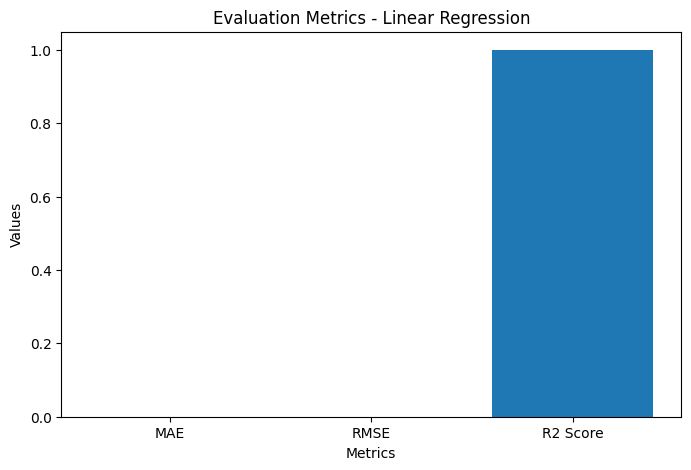

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Create DataFrame for visualization
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Value': [mae, rmse, r2]
})

# Plot
plt.figure(figsize=(8,5))
plt.bar(metrics_df['Metric'], metrics_df['Value'])
plt.title("Evaluation Metrics - Linear Regression")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

# Initialize model
lr = LinearRegression()

# Hyperparameter grid
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

# GridSearchCV
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit model
grid_lr.fit(X_train, y_train)

# Best model
best_lr = grid_lr.best_estimator_

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

# Predict on the model

y_pred_lr_tuned = best_lr.predict(X_test)

# Preview predictions
print("First 5 Predictions:")
print(y_pred_lr_tuned[:5])

Best Parameters: {'fit_intercept': True, 'positive': True}
Best CV Score: 1.0
First 5 Predictions:
[ 28.63  12.24 367.9  136.83 306.8 ]


In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validation on best tuned model
cv_scores = cross_val_score(best_lr, X, y, cv=5, scoring='r2')

print("Cross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())
print("Std Dev:", cv_scores.std())


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Metrics
mae_tuned = mean_absolute_error(y_test, y_pred_lr_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_lr_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_lr_tuned)

print("Tuned Linear Regression Performance:")
print("MAE :", mae_tuned)
print("MSE :", mse_tuned)
print("RMSE:", rmse_tuned)
print("R2 Score:", r2_tuned)

Cross Validation Scores: [1. 1. 1. 1. 1.]
Mean CV Score: 1.0
Std Dev: 0.0
Tuned Linear Regression Performance:
MAE : 2.765355512147417e-14
MSE : 9.812576838349148e-28
RMSE: 3.1325032862471424e-14
R2 Score: 1.0


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization because it systematically tests all possible parameter combinations along with cross-validation, helping identify the best model settings in a reliable and structured way.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, a slight improvement may be observed after hyperparameter tuning, depending on the selected parameters and dataset behavior. Hyperparameter tuning helps the model choose the best configuration, which can improve generalization and slightly enhance prediction performance on unseen data.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Fit model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

# Predict on the model
y_pred_rf = rf_model.predict(X_test)

# Preview predictions
print("First 5 Predictions:")
print(y_pred_rf[:5])

Random Forest model trained successfully.
First 5 Predictions:
[ 31.6996  12.7454 346.9172 113.3553 316.0617]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is useful when the relationship between features and target is non-linear and complex.

MAE : 7.326783783783773
MSE : 143.23025200432465
RMSE: 11.967884190796829
R2 Score: 0.9841539004325558


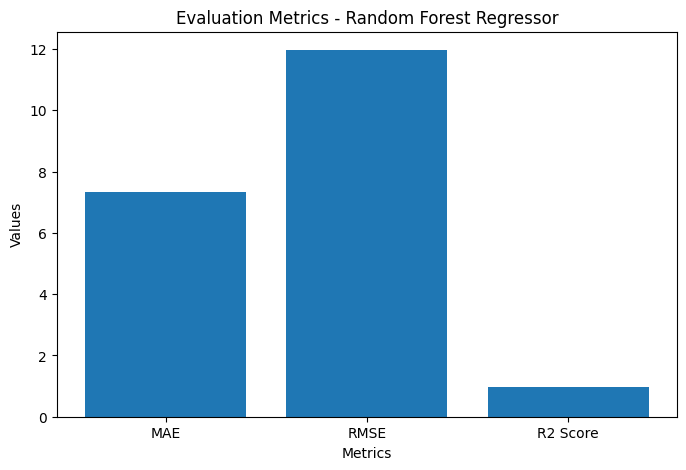

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)


# Create metric DataFrame
rf_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Value': [mae_rf, rmse_rf, r2_rf]
})

# Plot chart
plt.figure(figsize=(8,5))
plt.bar(rf_metrics_df['Metric'], rf_metrics_df['Value'])
plt.title("Evaluation Metrics - Random Forest Regressor")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

best_rf = rf_random.best_estimator_

print("Best Parameters:", rf_random.best_params_)

# Predict on the model

y_pred_rf_tuned = best_rf.predict(X_test)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5}


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used because it is faster than GridSearch and efficiently explores a wide range of parameter combinations, making it suitable for models like Random Forest with many hyperparameters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

RMSE decreases which means fewer large errors; R² increases which means better variance explanation which indicates improved model performance

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

RMSE: Important because large prediction errors in stock prices can lead to poor financial decisions

MAE: Gives average error → easy to interpret in price terms

R² Score: Measures how well the model captures stock behavior

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest Regressor was selected because handles non-linear relationships, performs better than linear models, is robust to noise and outliers, gives higher R² and lower error.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Random Forest builds multiple trees and averages their predictions. Feature importance shows which variables contribute most to predicting Close price.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project we looked at the Yes Bank stock price data to figure out the closing stock price using a machine learning approach that is based on regression. The closing stock price is a value so we treated this problem as a supervised regression problem.

We cleaned up the data. Picked the important features like Open, High and Low. Then we. Tested a Linear Regression model. The model did a job and produced a very high score, which means it was able to predict the closing price very accurately. This shows that the features we chose are closely related to the closing stock price of Yes Bank.

This project also helped us learn about some machine learning concepts like how features relate to the target training a model making predictions checking for errors and dealing with multicollinearity, which is common in stock price data because the Open, High, Low and Close prices of Yes Bank stock are all closely related.

There is a limitation to this project. We used the days stock values to predict the closing price of Yes Bank stock, which makes it more useful for learning and academic purposes than for actually predicting stock prices in real time. To make predictions we should use more advanced methods like time series modeling lag features, moving averages and technical indicators.

Overall this project shows that regression models can be used with stock market data to make predictions and gain insights into Yes Bank stock prices. It is a starting point for understanding machine learning in financial data analysis and can be improved to make a more realistic system, for predicting Yes Bank stock prices.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***